In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/Clean Data')
print(os.listdir())


Mounted at /content/drive
['df_census.csv', 'df_people.csv', 'df_crashes.csv', 'df_vehicles.csv', 'df_redlights.csv', 'df_speeding.csv', 'df_cameras.csv', 'catboost_info', 'injury_severity_model.pkl']


In [ ]:
import pandas as pd
df_crashes=pd.read_csv("df_crashes.csv")

# print(df_crashes.info())
# print(df_crashes.describe())


<H1>Data PreProcessing and Feature Engineering</H1>

In [ ]:
import pandas as pd

df = df_crashes.copy()

# --- 1) Make the binary target ---
df["SEVERE_BIN"] = ((df["INJURIES_FATAL"] > 0) | (df["INJURIES_INCAPACITATING"] > 0)).astype(int)

# Quick sanity check on class balance
pos = df["SEVERE_BIN"].sum()
neg = (1 - df["SEVERE_BIN"]).sum()
print(f"Severe=1: {pos:,}  |  Non-severe=0: {neg:,}  |  Pos-rate: {pos/len(df):.4%}")

# --- 2) Drop outcome leakage + identifiers ---
leakage_cols = [
    # direct outcomes / near-outcomes
    "INJURIES_TOTAL","INJURIES_FATAL","INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING","INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION","MOST_SEVERE_INJURY","DAMAGE",
    # timestamps/IDs/free-text not meant for modeling
    "CRASH_RECORD_ID","CRASH_DATE","DATE_POLICE_NOTIFIED",
    "STREET_NO","STREET_NAME"
]

# keep causes for now (they are predictive and available in reports);


X = df.drop(columns=leakage_cols + ["SEVERE_BIN"])
y = df["SEVERE_BIN"]

# ---Remove BEAT_OF_OCCURRENCE ---
if "BEAT_OF_OCCURRENCE" in X.columns:
    X = X.drop(columns=["BEAT_OF_OCCURRENCE"])

# ---Convert time & region columns to categorical ---
cat_time_cols = ["CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "zipcode"]

# Fill missing zipcodes with a placeholder (string) before converting
X["zipcode"] = X["zipcode"].fillna("unknown").astype(str)

for col in cat_time_cols:
    X[col] = X[col].astype("category")


# copy
df_model = X.copy()

# -Numeric, binary, and categorical base features ---
numeric_cols = [
    'POSTED_SPEED_LIMIT','NUM_UNITS','LATITUDE','LONGITUDE'
]
binary_cols = ['INTERSECTION_RELATED_I','HIT_AND_RUN_I']
cat_cols = [
    'TRAFFIC_CONTROL_DEVICE','DEVICE_CONDITION','WEATHER_CONDITION','LIGHTING_CONDITION',
    'FIRST_CRASH_TYPE','TRAFFICWAY_TYPE','ALIGNMENT','ROADWAY_SURFACE_COND',
    'ROAD_DEFECT','REPORT_TYPE','CRASH_TYPE','PRIM_CONTRIBUTORY_CAUSE',
    'SEC_CONTRIBUTORY_CAUSE','STREET_DIRECTION','CRASH_HOUR','CRASH_DAY_OF_WEEK',
    'CRASH_MONTH','zipcode'
]

# -Feature engineering ---
# Weekend indicator
df_model['IS_WEEKEND'] = df_model['CRASH_DAY_OF_WEEK'].apply(lambda x: 1 if int(x) >= 6 else 0)

# Nighttime indicator
df_model['IS_NIGHT'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (int(x) <= 6) or (int(x) >= 20) else 0)

# Rush hour indicator
df_model['RUSH_HOUR'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (7 <= int(x) <= 9) or (16 <= int(x) <= 18) else 0)

# Hazardous weather indicator — broad list of risky types
hazardous_weather = [
    'RAIN', 'SNOW', 'FOG/SMOKE/HAZE', 'FREEZING RAIN/DRIZZLE',
    'SLEET/HAIL', 'BLOWING SNOW', 'BLOWING SAND, SOIL, DIRT',
    'SEVERE CROSS WIND GATE'
]
df_model['IS_RAIN_SNOW'] = df_model['WEATHER_CONDITION'].apply(
    lambda w: 1 if str(w).upper() in hazardous_weather else 0
)

# High-speed zone indicator
df_model['HIGH_SPEED_ZONE'] = df_model['POSTED_SPEED_LIMIT'].apply(lambda s: 1 if s >= 40 else 0)

# --- Final engineered feature list ---
engineered_cols = ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW','HIGH_SPEED_ZONE']

# ---Final column groups ---
numeric_cols_final = numeric_cols + ['HIGH_SPEED_ZONE']
binary_cols_final = binary_cols + ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW']
categorical_cols_final = cat_cols

print(f"Numeric columns ({len(numeric_cols_final)}):", numeric_cols_final)
print(f"Binary columns ({len(binary_cols_final)}):", binary_cols_final)
print(f"Categorical columns ({len(categorical_cols_final)}):", categorical_cols_final)
print("\n Total final features:", len(numeric_cols_final) + len(binary_cols_final) + len(categorical_cols_final))
print("DataFrame shape:", df_model.shape)
df_model.head()




Severe=1: 15,791  |  Non-severe=0: 933,319  |  Pos-rate: 1.6638%
Numeric columns (5): ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'LATITUDE', 'LONGITUDE', 'HIGH_SPEED_ZONE']
Binary columns (6): ['INTERSECTION_RELATED_I', 'HIT_AND_RUN_I', 'IS_WEEKEND', 'IS_NIGHT', 'RUSH_HOUR', 'IS_RAIN_SNOW']
Categorical columns (18): ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_DIRECTION', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'zipcode']

 Total final features: 29
DataFrame shape: (949110, 29)


,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,...,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,zipcode,IS_WEEKEND,IS_NIGHT,RUSH_HOUR,IS_RAIN_SNOW,HIGH_SPEED_ZONE
0,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,"DARKNESS, LIGHTED ROAD",REAR TO FRONT,FOUR WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.968643,-87.698492,60625.0,0,1,0,1,0
1,30,NO CONTROLS,NO CONTROLS,OTHER,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,OTHER,NO DEFECTS,...,3,10,41.826667,-87.689679,60632.0,0,1,0,0,0
2,25,STOP SIGN/FLASHER,UNKNOWN,RAIN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,T-INTERSECTION,STRAIGHT AND LEVEL,WET,UNKNOWN,...,3,10,41.885533,-87.759074,60644.0,0,1,0,1,0
3,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.823030,-87.621437,60653.0,0,1,0,0,0
4,35,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,2,10,41.828208,-87.670489,60609.0,0,1,0,0,0


<h1>Model Selection Test</H1>


================== DummyClassifier ==================

ROC-AUC  : 0.5000
PR-AUC   : 0.0166

Classification Report:
              precision    recall  f1-score   support

           0      0.983     1.000     0.992    186664
           1      0.000     0.000     0.000      3158

    accuracy                          0.983    189822
   macro avg      0.492     0.500     0.496    189822
weighted avg      0.967     0.983     0.975    189822



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


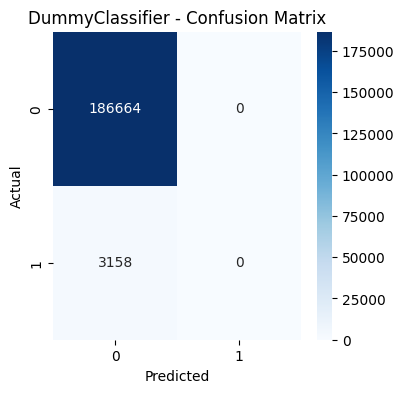


================== Logistic Regression (Balanced) ==================

ROC-AUC  : 0.9245
PR-AUC   : 0.1461

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.767     0.868    186664
           1      0.067     0.982     0.125      3158

    accuracy                          0.770    189822
   macro avg      0.533     0.875     0.496    189822
weighted avg      0.984     0.770     0.856    189822



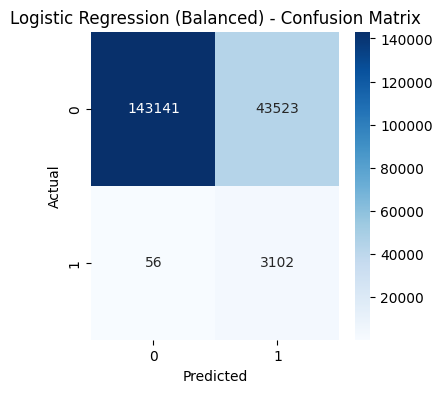


================== Random Forest (Balanced, OHE) ==================

ROC-AUC  : 0.9181
PR-AUC   : 0.1345

Classification Report:
              precision    recall  f1-score   support

           0      0.998     0.797     0.887    186664
           1      0.072     0.926     0.133      3158

    accuracy                          0.799    189822
   macro avg      0.535     0.862     0.510    189822
weighted avg      0.983     0.799     0.874    189822



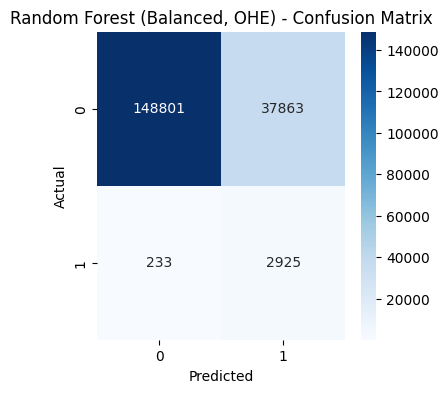

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# ================================================================
# Train/test split (same for all models)
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    df_model, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ================================================================
# Helper to evaluate and plot confusion matrix
# ================================================================
def evaluate(model_name, model, X_test, y_test):
    print(f"\n================== {model_name} ==================\n")

    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)

    # Metrics
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, digits=3))

    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ================================================================
# 1. DUMMY CLASSIFIER (Most Frequent Strategy)
# ================================================================
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
evaluate("DummyClassifier", dummy, X_test, y_test)


# ================================================================
# 2. LOGISTIC REGRESSION (with One-Hot Encoding)
# ================================================================
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_final)
    ],
    remainder="passthrough"
)

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", logreg)])
pipe.fit(X_train, y_train)
evaluate("Logistic Regression (Balanced)", pipe, X_test, y_test)


# ================================================================
# 3. RANDOM FOREST (Tree Baseline) with OneHotEncoding
# ================================================================

preprocess_rf = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_final)
    ],
    remainder="passthrough"  # numeric + binary come through unchanged
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

pipe_rf = Pipeline(steps=[
    ("prep", preprocess_rf),
    ("model", rf)
])

pipe_rf.fit(X_train, y_train)

evaluate("Random Forest (Balanced, OHE)", pipe_rf, X_test, y_test)



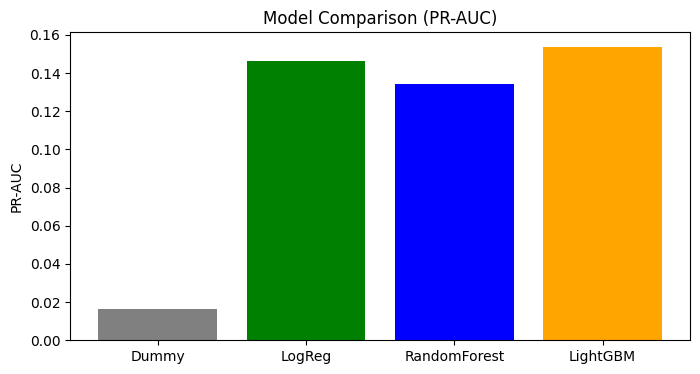

In [9]:
import matplotlib.pyplot as plt

models = ["Dummy", "LogReg", "RandomForest", "LightGBM"]
pr_auc_scores = [0.0166, 0.1461, 0.1345, 0.1537]

plt.figure(figsize=(8,4))
plt.bar(models, pr_auc_scores, color=['gray','green','blue','orange'])
plt.ylabel("PR-AUC")
plt.title("Model Comparison (PR-AUC)")
plt.show()


<p>Although Logistic Regression had a slightly higher PR-AUC than Random Forest, we moved toward tree-based gradient boosting because the problem requires modeling complex non-linear interactions and categorical relationships that linear models cannot capture. Random Forest served as our baseline tree model, and based on that signal we proceeded with LightGBM, which is the state-of-the-art for tabular, non-linear, imbalanced datasets.</p>

In [10]:
# LightGB Model Train

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve
)
import numpy as np


# ================================================================
# Helper function to train + evaluate model
# ================================================================
def run_lgbm_experiment(class_weight_value):

    print("\n" + "="*80)
    print(f" Running LightGBM Experiment | class_weight = {class_weight_value}")
    print("="*80)

    # ---------------- Train/test split ----------------
    X_train, X_test, y_train, y_test = train_test_split(
        df_model, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
    print("Severe rate (train):", y_train.mean().round(4),
          "| (test):", y_test.mean().round(4))

    # ---------------- Categorical dtype fix ----------------
    for col in categorical_cols_final:
        X_train[col] = X_train[col].astype("category")
        X_test[col] = X_test[col].astype("category")

    cat_features = [
        col for col in X_train.columns if str(X_train[col].dtype) == "category"
    ]
    print("Categorical features:", cat_features)

    # ---------------- LightGBM model ----------------
    model = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=127,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        class_weight=class_weight_value,
        n_jobs=-1
    )

    # ---------------- Training with early stopping ----------------
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        categorical_feature=cat_features,
        callbacks=[early_stopping(stopping_rounds=100),
                   log_evaluation(period=100)]
    )

    # ---------------- Predictions ----------------
    probs = model.predict_proba(X_test)[:, 1]
    pred_05 = (probs >= 0.5).astype(int)

    # ---------------- Default threshold metrics ----------------
    print("\n====== Default Threshold (0.5) ======")
    print("ROC-AUC :", roc_auc_score(y_test, probs).round(4))
    print("PR-AUC  :", average_precision_score(y_test, probs).round(4))
    print("\nClassification Report:\n", classification_report(y_test, pred_05, digits=3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred_05))

    # ---------------- F2 threshold tuning ----------------
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    beta = 2.0
    f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)

    best_idx = np.nanargmax(f2)
    best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

    pred_best = (probs >= best_thresh).astype(int)

    print(f"\n====== Best F2 Threshold: {best_thresh:.3f} ======")
    print("Classification Report @Best-F2:\n",
          classification_report(y_test, pred_best, digits=3))
    print("Confusion Matrix @Best-F2:\n", confusion_matrix(y_test, pred_best))

    return model, best_thresh,X_train, X_test, y_train, y_test


In [11]:
# model with no class weight
model_no_weight, t1,X_train, X_test, y_train, y_test= run_lgbm_experiment(class_weight_value=None)

# model with class weight balanced
model_balanced, t2, X_train, X_test, y_train, y_test= run_lgbm_experiment(class_weight_value="balanced")



 Running LightGBM Experiment | class_weight = None
Train shape: (759288, 29) | Test shape: (189822, 29)
Severe rate (train): 0.0166 | (test): 0.0166
Categorical features: ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_DIRECTION', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'zipcode']
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] featur

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


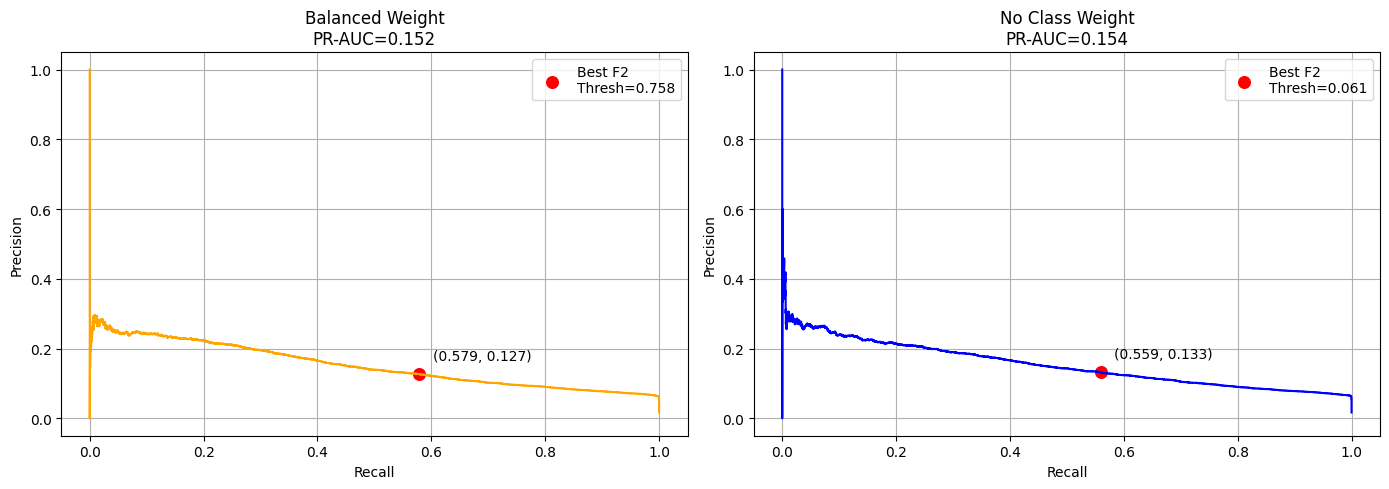

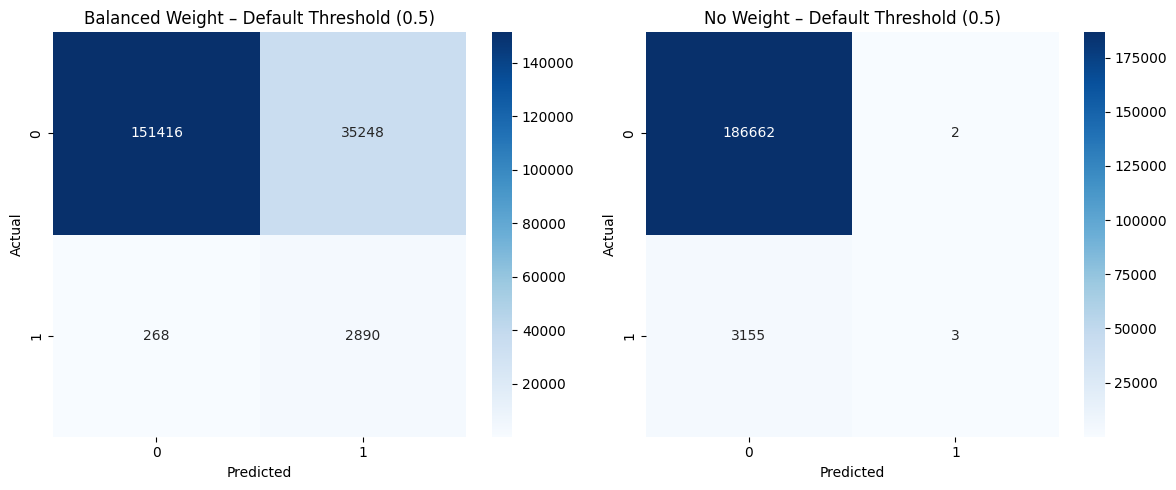

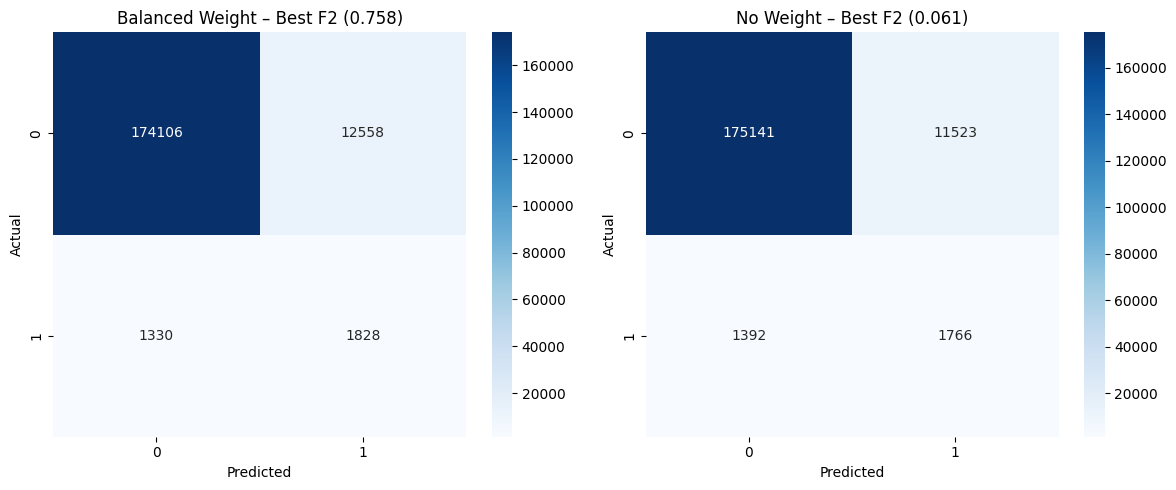


==================== SUMMARY ====================
No Class Weight | PR-AUC = 0.1537 | Best F2 Thresh = 0.061
Class Weight    | PR-AUC = 0.1521 | Best F2 Thresh = 0.758


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    confusion_matrix
)
import seaborn as sns
import numpy as np


# ================================================================
# Function to evaluate model
# ================================================================
def evaluate_model(model, X_test, y_test, label):

    probs = model.predict_proba(X_test)[:, 1]

    # Precision–Recall values + thresholds
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    # F2 threshold
    beta = 2
    f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
    best_idx = np.nanargmax(f2)

    # Note: thresholds array has length = len(rec)-1
    best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

    # Predictions at best F2
    pred_f2 = (probs >= best_thresh).astype(int)

    # Confusion matrices
    pred_05 = (probs >= 0.5).astype(int)
    cm_default = confusion_matrix(y_test, pred_05)
    cm_f2 = confusion_matrix(y_test, pred_f2)

    return {
        "label": label,
        "probs": probs,
        "prec": prec,
        "rec": rec,
        "thresh": thresh,
        "pr_auc": pr_auc,
        "cm_default": cm_default,
        "cm_f2": cm_f2,
        "best_thresh": best_thresh,
        "best_idx": best_idx
    }


# ================================================================
# Run both evaluations
# ================================================================
results_no_weight = evaluate_model(model_no_weight, X_test, y_test, "No Class Weight")
results_weighted  = evaluate_model(model_balanced, X_test, y_test, "Class Weight = balanced")


# ================================================================
# 1) NORMAL PR CURVES + BEST F2 DOT
# ================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------- Balanced Weight --------
rec_w = results_weighted["rec"][results_weighted["best_idx"]]
prec_w = results_weighted["prec"][results_weighted["best_idx"]]

ax[0].plot(results_weighted["rec"], results_weighted["prec"], color='orange')
ax[0].scatter(rec_w, prec_w, color="red", s=70, label=f"Best F2\nThresh={results_weighted['best_thresh']:.3f}")
ax[0].annotate(f"({rec_w:.3f}, {prec_w:.3f})",
               (rec_w, prec_w), textcoords="offset points", xytext=(10,10))

ax[0].set_title(f"Balanced Weight\nPR-AUC={results_weighted['pr_auc']:.3f}")
ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].grid(True)
ax[0].legend()


# -------- No Class Weight --------
rec_nw = results_no_weight["rec"][results_no_weight["best_idx"]]
prec_nw = results_no_weight["prec"][results_no_weight["best_idx"]]

ax[1].plot(results_no_weight["rec"], results_no_weight["prec"], color='blue')
ax[1].scatter(rec_nw, prec_nw, color="red", s=70, label=f"Best F2\nThresh={results_no_weight['best_thresh']:.3f}")
ax[1].annotate(f"({rec_nw:.3f}, {prec_nw:.3f})",
               (rec_nw, prec_nw), textcoords="offset points", xytext=(10,10))

ax[1].set_title(f"No Class Weight\nPR-AUC={results_no_weight['pr_auc']:.3f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


# ================================================================
# CONFUSION MATRICES (DEFAULT & BEST F2)
# ================================================================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(results_weighted["cm_default"], annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Balanced Weight – Default Threshold (0.5)")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")

sns.heatmap(results_no_weight["cm_default"], annot=True, fmt="d", cmap="Blues", ax=ax[1])
ax[1].set_title("No Weight – Default Threshold (0.5)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(results_weighted["cm_f2"], annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title(f"Balanced Weight – Best F2 ({results_weighted['best_thresh']:.3f})")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")

sns.heatmap(results_no_weight["cm_f2"], annot=True, fmt="d", cmap="Blues", ax=ax[1])
ax[1].set_title(f"No Weight – Best F2 ({results_no_weight['best_thresh']:.3f})")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()


# ================================================================
# SUMMARY PRINT
# ================================================================
print("\n==================== SUMMARY ====================")
print(f"No Class Weight | PR-AUC = {results_no_weight['pr_auc']:.4f} | Best F2 Thresh = {results_no_weight['best_thresh']:.3f}")
print(f"Class Weight    | PR-AUC = {results_weighted['pr_auc']:.4f} | Best F2 Thresh = {results_weighted['best_thresh']:.3f}")


<h1>The PR curve shows a clear trade-off: increasing recall reduces precision and vice-versa.</h1>
<P> In our accident severity model, the operationally useful region is recall 0.05–0.30, where precision stabilizes around 0.25–0.30. Below 0.05, recall is too low to be actionable, and above 0.30, precision falls too much, leading to excessive false alarms.”</P>

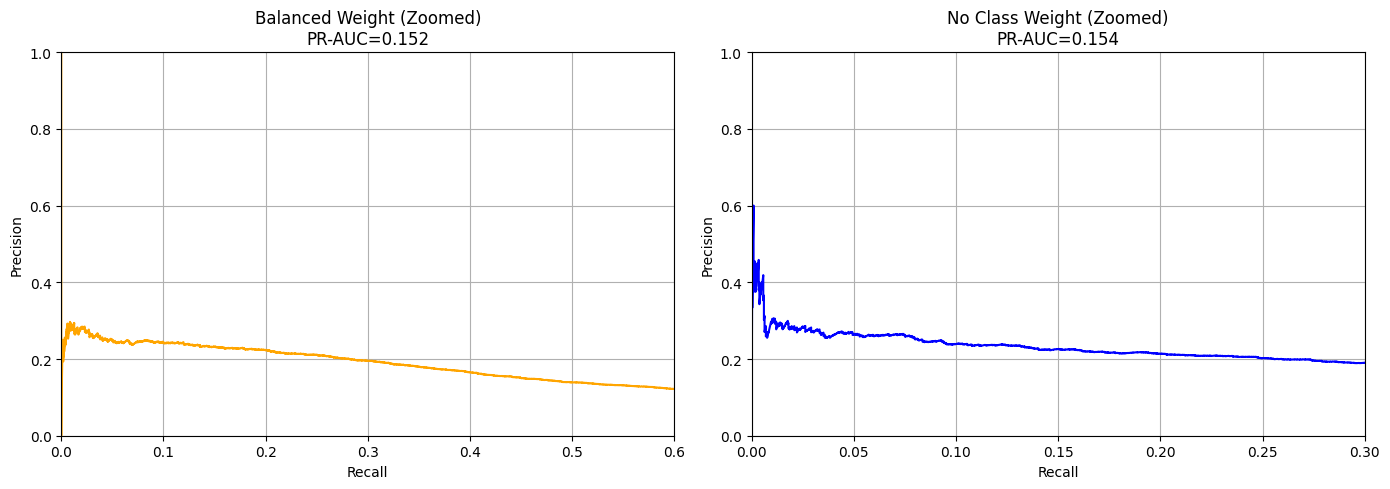

In [ ]:
# ================================================================
# ZOOMED PR CURVES SIDE BY SIDE (Recall 0–0.2)
# ================================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ----- Left: Balanced Weight -----
ax[0].plot(results_weighted["rec"], results_weighted["prec"], color='orange')
ax[0].set_title(f"Balanced Weight (Zoomed)\nPR-AUC={results_weighted['pr_auc']:.3f}")
ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_xlim(0, 0.6)        # ZOOM X-AXIS
ax[0].set_ylim(0, 1.0)         # Keep precision full range
ax[0].grid(True)

# ----- Right: No Class Weight -----
ax[1].plot(results_no_weight["rec"], results_no_weight["prec"], color='blue')
ax[1].set_title(f"No Class Weight (Zoomed)\nPR-AUC={results_no_weight['pr_auc']:.3f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_xlim(0, 0.3)        # ZOOM X-AXIS
ax[1].set_ylim(0, 1.0)
ax[1].grid(True)

plt.tight_layout()
plt.show()


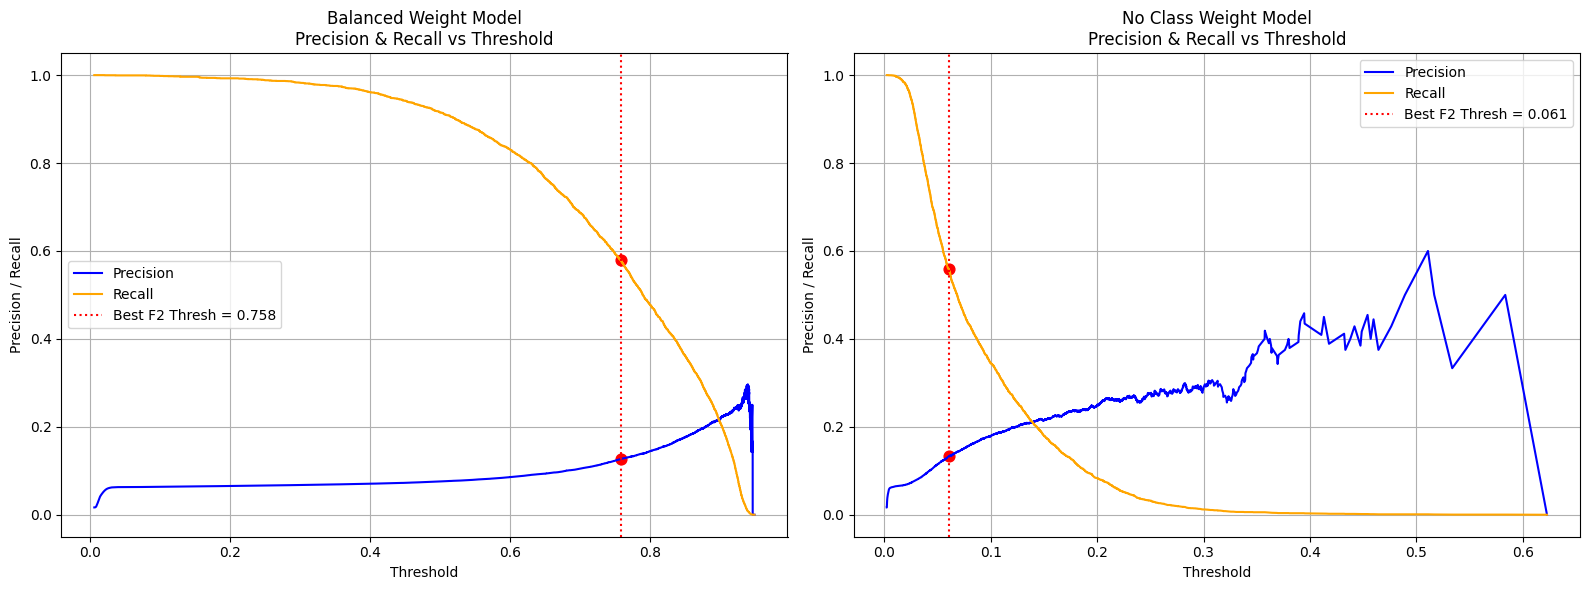

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================================================
# Extract model curves
# ================================================================
prec_w  = results_weighted["prec"][:-1]
rec_w   = results_weighted["rec"][:-1]
th_w    = results_weighted["thresh"]

prec_nw = results_no_weight["prec"][:-1]
rec_nw  = results_no_weight["rec"][:-1]
th_nw   = results_no_weight["thresh"]

best_th_w  = results_weighted["best_thresh"]
best_th_nw = results_no_weight["best_thresh"]

best_idx_w  = np.argmin(np.abs(th_w - best_th_w))
best_idx_nw = np.argmin(np.abs(th_nw - best_th_nw))


# ================================================================
# PLOT: Precision & Recall vs Threshold (side-by-side)
# ================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))


# ---------------------------------------------------------
# LEFT: BALANCED WEIGHT MODEL
# ---------------------------------------------------------
ax[0].plot(th_w, prec_w, color="blue", label="Precision")
ax[0].plot(th_w, rec_w,  color="orange", label="Recall")

# Best threshold line
ax[0].axvline(best_th_w, color="red", linestyle=":", label=f"Best F2 Thresh = {best_th_w:.3f}")

# Dots on curves
ax[0].scatter(best_th_w, prec_w[best_idx_w], color="red", s=60)
ax[0].scatter(best_th_w, rec_w[best_idx_w],  color="red", s=60)

ax[0].set_title("Balanced Weight Model\nPrecision & Recall vs Threshold")
ax[0].set_xlabel("Threshold")
ax[0].set_ylabel("Precision / Recall")
ax[0].grid(True)
ax[0].legend()


# ---------------------------------------------------------
# RIGHT: NO CLASS WEIGHT MODEL
# ---------------------------------------------------------
ax[1].plot(th_nw, prec_nw, color="blue", label="Precision")
ax[1].plot(th_nw, rec_nw,  color="orange", label="Recall")

# Best threshold line
ax[1].axvline(best_th_nw, color="red", linestyle=":", label=f"Best F2 Thresh = {best_th_nw:.3f}")

# Dots on curves
ax[1].scatter(best_th_nw, prec_nw[best_idx_nw], color="red", s=60)
ax[1].scatter(best_th_nw, rec_nw[best_idx_nw],  color="red", s=60)

ax[1].set_title("No Class Weight Model\nPrecision & Recall vs Threshold")
ax[1].set_xlabel("Threshold")
ax[1].set_ylabel("Precision / Recall")
ax[1].grid(True)
ax[1].legend()


plt.tight_layout()
plt.show()


In [ ]:
#hyper parameter tuning
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve
)
import numpy as np
import pandas as pd

# 1. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    df_model, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ensure categoricals
for col in categorical_cols_final:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

cat_features = [c for c in X_train.columns if str(X_train[c].dtype) == "category"]

print("Train severe rate:", y_train.mean(), "| Test severe rate:", y_test.mean())

# ================================================================
# 2. DEFINE HYPERPARAMETER GRID (CURATED FOR LIGHTGBM)
# ================================================================
param_grid = [
    {"learning_rate": 0.05, "num_leaves": 127, "min_child_samples": 20},
    {"learning_rate": 0.03, "num_leaves": 127, "min_child_samples": 50},
    {"learning_rate": 0.07, "num_leaves": 127, "min_child_samples": 100},
    {"learning_rate": 0.05, "num_leaves": 63,  "min_child_samples": 50},
    {"learning_rate": 0.05, "num_leaves": 255, "min_child_samples": 50},
    {"learning_rate": 0.03, "num_leaves": 255, "min_child_samples": 100},
]

results = []

# ================================================================
# 3. TRAIN/EVALUATE FOR EACH PARAMETER SET
# ================================================================
for i, params in enumerate(param_grid, 1):
    print(f"\n\n==================== Trial {i} ====================")
    print("Params:", params)

    model = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        categorical_feature=cat_features,
        callbacks=[early_stopping(stopping_rounds=100)]
    )

    # Predict
    probs = model.predict_proba(X_test)[:, 1]

    # Metrics
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    # F2 threshold tuning
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    beta = 2
    f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
    best_idx = np.nanargmax(f2)
    best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

    pred_best = (probs >= best_thresh).astype(int)
    report = classification_report(y_test, pred_best, output_dict=True)

    precision_1 = report["1"]["precision"]
    recall_1 = report["1"]["recall"]
    f2_best = (1 + beta**2) * ((precision_1 * recall_1) / (beta**2 * precision_1 + recall_1 + 1e-12))

    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(f"Best Threshold: {best_thresh:.3f}")
    print(f"Precision1: {precision_1:.3f} | Recall1: {recall_1:.3f} | F2: {f2_best:.3f}")

    results.append({
        "trial": i,
        **params,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_thresh": best_thresh,
        "precision1": precision_1,
        "recall1": recall_1,
        "f2": f2_best
    })

# ================================================================
# 4. PRINT SUMMARY TABLE
# ================================================================
results_df = pd.DataFrame(results)
print("\n==================== SUMMARY RESULTS ====================")
print(results_df[['trial','learning_rate','num_leaves','min_child_samples','roc_auc','pr_auc','precision1','recall1','f2']])


Train severe rate: 0.016637955558365204 | Test severe rate: 0.016636638535048626


==================== Trial 1 ====================
Params: {'learning_rate': 0.05, 'num_leaves': 127, 'min_child_samples': 20}
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 12633, number of negative: 746655
[LightGBM] [Info] Aut

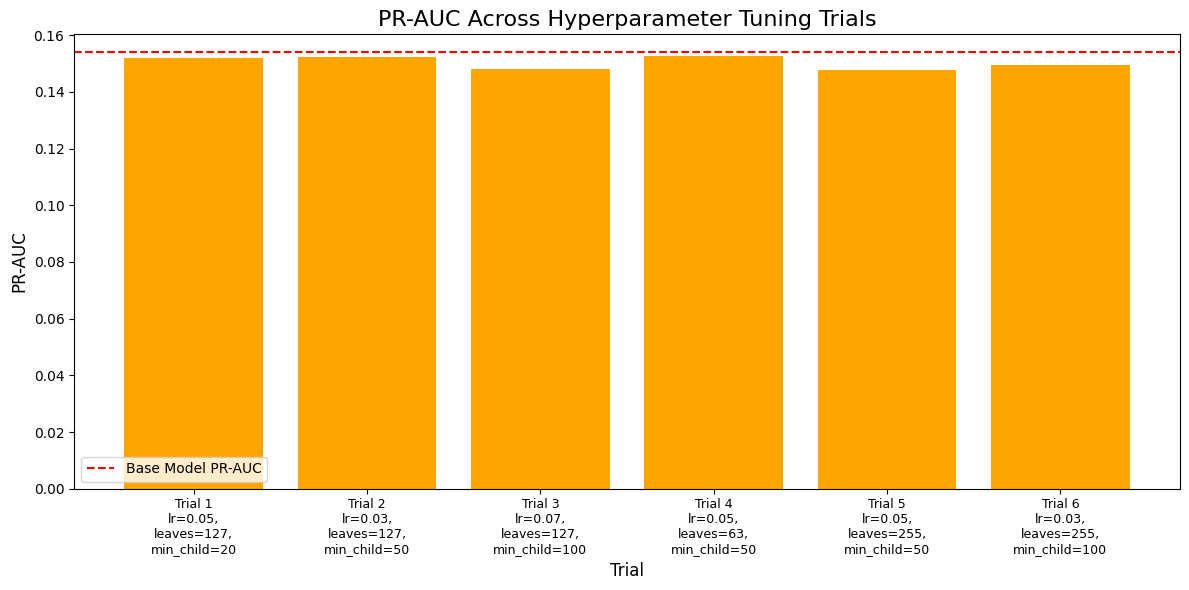

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bars = plt.bar(results_df["trial"], results_df["pr_auc"], color='orange')

# Base model reference
plt.axhline(y=0.154, color='red', linestyle='--', label='Base Model PR-AUC')

plt.title("PR-AUC Across Hyperparameter Tuning Trials", fontsize=16)
plt.xlabel("Trial", fontsize=12)
plt.ylabel("PR-AUC", fontsize=12)
plt.legend()

# ---------------------------
# Add readable labels BELOW each bar
# ---------------------------
hp_labels = []
for hp in param_grid:
    hp_labels.append(
        f"lr={hp['learning_rate']},\n"
        f"leaves={hp['num_leaves']},\n"
        f"min_child={hp['min_child_samples']}"
    )

plt.xticks(
    ticks=results_df["trial"],
    labels=[f"Trial {i}\n{hp_labels[i-1]}" for i in results_df["trial"]],
    rotation=0,
    fontsize=9
)

plt.tight_layout()
plt.show()


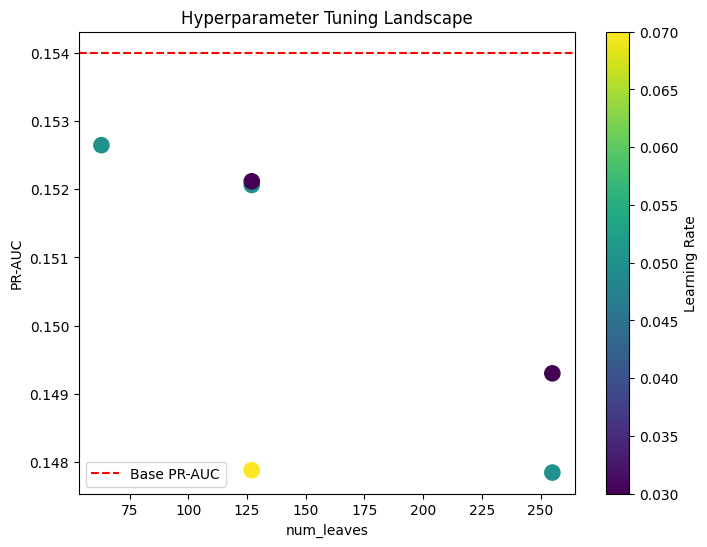

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(results_df["num_leaves"], results_df["pr_auc"],
            c=results_df["learning_rate"], cmap='viridis', s=120)
plt.colorbar(label="Learning Rate")
plt.axhline(0.154, color='red', linestyle="--", label="Base PR-AUC")
plt.xlabel("num_leaves")
plt.ylabel("PR-AUC")
plt.title("Hyperparameter Tuning Landscape")
plt.legend()
plt.show()


<h1>The baseline LightGBM model with out class weight and f2 tuning  is optimal.</h1>
Additional hyperparameter tuning does not significantly improve predictive performance.


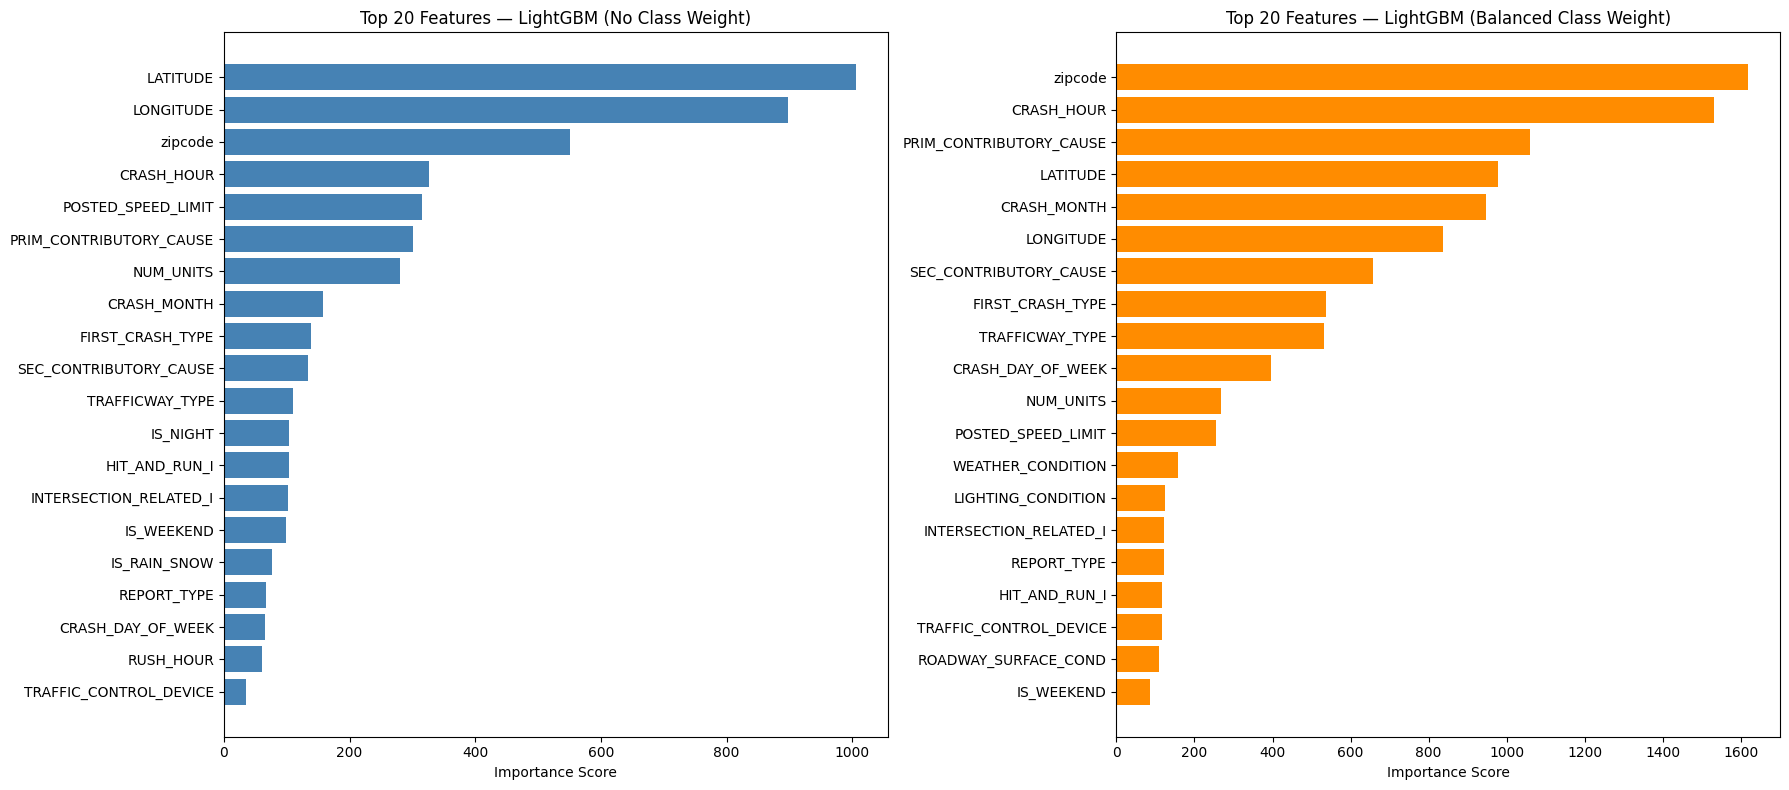

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ================================================================
# Side-by-Side Feature Importance (Base vs Balanced)
# ================================================================

# Base model
imp_base = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_no_weight.feature_importances_
}).sort_values("importance", ascending=False)

# Balanced model
imp_bal = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_balanced.feature_importances_
}).sort_values("importance", ascending=False)

# Top 20 features
top_base = imp_base.head(20)
top_bal = imp_bal.head(20)

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# ----- Left: Base (No Class Weight) -----
ax[0].barh(top_base["feature"][::-1], top_base["importance"][::-1], color="steelblue")
ax[0].set_title("Top 20 Features — LightGBM (No Class Weight)")
ax[0].set_xlabel("Importance Score")

# ----- Right: Balanced -----
ax[1].barh(top_bal["feature"][::-1], top_bal["importance"][::-1], color="darkorange")
ax[1].set_title("Top 20 Features — LightGBM (Balanced Class Weight)")
ax[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


In [ ]:
!pip install shap


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


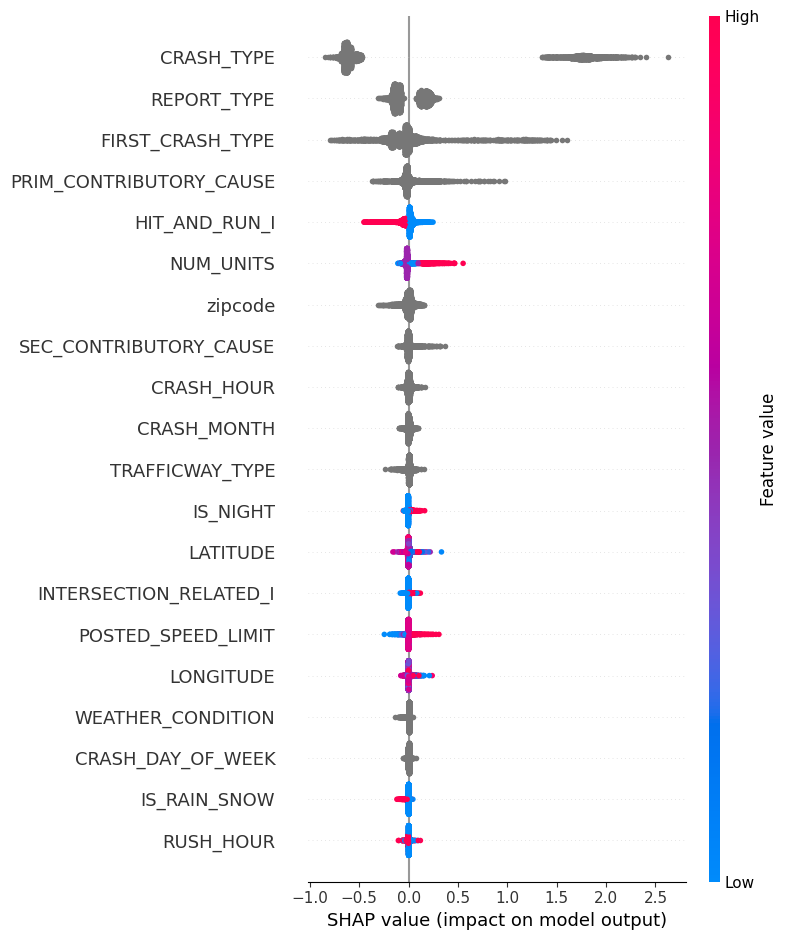

In [ ]:
import shap

# Use TreeExplainer for LightGBM
explainer = shap.TreeExplainer(model_no_weight)

# Use a sample of test data for speed (SHAP on 190k rows is heavy)
X_sample = X_test.sample(5000, random_state=42)

shap_values = explainer.shap_values(X_sample)

# SHAP Summary Plot (Bee Swarm)
shap.summary_plot(shap_values, X_sample, plot_type="dot")


In [ ]:
# --- reduced feature set without contributory causes ---
X_reduced = df_model.drop(columns=['PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE'])
y_reduced = y

# Keep categorical dtype conversions for remaining categorical columns
for col in categorical_cols_final:
    if col in X_reduced.columns:
        X_reduced[col] = X_reduced[col].astype('category')

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_reduced,
    test_size=0.2, random_state=42, stratify=y_reduced
)

lgbm_reduced = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=127,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        class_weight=None,
        n_jobs=-1
    )

lgbm_reduced.fit(
    X_train_r, y_train_r,
    categorical_feature=[c for c in X_reduced.columns if str(X_reduced[c].dtype) == 'category'],
    eval_set=[(X_test_r, y_test_r)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=100)]
)

# --- Evaluate ---
# --- Default 0.5 threshold ---
probs_r = lgbm_reduced.predict_proba(X_test_r)[:,1]
pred_r_05 = (probs_r >= 0.5).astype(int)

print("\n================ Default Threshold (0.5) ================")
print("ROC-AUC :", roc_auc_score(y_test_r, probs_r).round(4))
print("PR-AUC  :", average_precision_score(y_test_r, probs_r).round(4))
print("\nClassification Report:\n", classification_report(y_test_r, pred_r_05, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test_r, pred_r_05))

# --- F2-based threshold tuning (recall-focused) ---
prec, rec, thresh = precision_recall_curve(y_test_r, probs_r)
beta = 2.0
f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
best_idx = np.nanargmax(f2)
best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

pred_best = (probs_r >= best_thresh).astype(int)

print(f"\n================ Best F2 Threshold: {best_thresh:.3f} ================")
print("Classification Report @Best-F2:\n", classification_report(y_test_r, pred_best, digits=3))
print("Confusion Matrix @Best-F2:\n", confusion_matrix(y_test_r, pred_best))



[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 12633, number of negative: 746655
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.153889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Lig

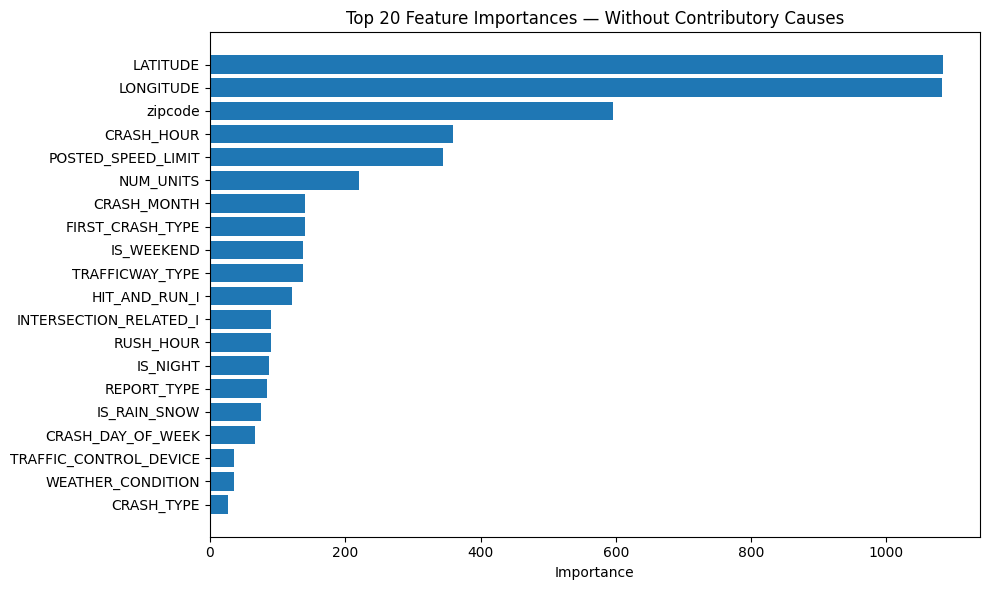

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Get new feature importances ---
importance_df_reduced = pd.DataFrame({
    'feature': lgbm_reduced.feature_name_,
    'importance': lgbm_reduced.feature_importances_
}).sort_values('importance', ascending=False)

# --- Plot the top 20 important features ---
plt.figure(figsize=(10, 6))
plt.barh(importance_df_reduced['feature'][:20][::-1], importance_df_reduced['importance'][:20][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances — Without Contributory Causes')
plt.tight_layout()
plt.show()



When contributory causes were removed, the model became more spatially biased, leaning heavily on latitude, longitude, and zipcode. This shift indicates that contributory causes were providing genuine behavioral and crash-mechanic information. Their absence forces the model to rely disproportionately on geographic features, reducing predictive diversity and lowering PR-AUC. Therefore, contributory causes are essential and are not leakage variables.

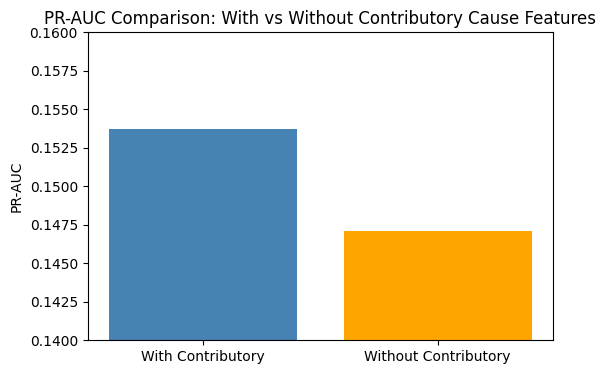

In [ ]:
import matplotlib.pyplot as plt

models = ["With Contributory", "Without Contributory"]
pr_auc_scores = [0.1537, 0.1471]

plt.figure(figsize=(6,4))
plt.bar(models, pr_auc_scores, color=["steelblue", "orange"])
plt.title("PR-AUC Comparison: With vs Without Contributory Cause Features")
plt.ylabel("PR-AUC")
plt.ylim(0.14, 0.16)
plt.show()


In [12]:
probs = model_no_weight.predict_proba(X_test)[:, 1]


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


<H1> Cost Based Approach</H1>

In [13]:
#Cost-Based Threshold Optimization
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_cost_thresholds(probs, y_test, COST_FN, COST_FP=1):
    thresholds = np.linspace(0.01, 0.99, 200)

    best_cost = float("inf")
    best_t = None
    best_stats = None

    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

        cost = COST_FN * fn + COST_FP * fp

        if cost < best_cost:
            best_cost = cost
            best_t = t
            best_stats = (tn, fp, fn, tp)

    tn, fp, fn, tp = best_stats

    print("\n====================================================")
    print(f"      COST-SENSITIVE OPTIMIZATION")
    print(f"      COST_FN = {COST_FN} | COST_FP = {COST_FP}")
    print("====================================================")
    print(f"Optimal Threshold: {best_t:.3f}")
    print(f"Minimum Total Cost: {best_cost:,}")
    print("\nConfusion Matrix:")
    print(f"TN={tn:,}   FP={fp:,}")
    print(f"FN={fn:,}   TP={tp:,}")

    print("\nClassification Report:\n")
    preds_final = (probs >= best_t).astype(int)
    print(classification_report(y_test, preds_final, digits=3))

    print("----------------------------------------------------")
    print(f"FN Count: {fn:,}  | FP Count: {fp:,}")
    print(f"Total Cost = {COST_FN}*FN + {COST_FP}*FP = {best_cost:,}")
    print("====================================================\n")

    return {
        "threshold": best_t,
        "cost": best_cost,
        "TN": tn, "FP": fp,
        "FN": fn, "TP": tp
    }


# ======================================================
# RUN COST ANALYSIS FOR BASELINE MODEL
# ======================================================

# your baseline probability predictions:
# probs = model_no_weight.predict_proba(X_test)[:, 1]   <-- YOU ALREADY HAVE THIS

results_cost_10 = evaluate_cost_thresholds(probs, y_test, COST_FN=10)
results_cost_20 = evaluate_cost_thresholds(probs, y_test, COST_FN=20)
results_cost_30 = evaluate_cost_thresholds(probs, y_test, COST_FN=30)



      COST-SENSITIVE OPTIMIZATION
      COST_FN = 10 | COST_FP = 1
Optimal Threshold: 0.079
Minimum Total Cost: 25,266

Confusion Matrix:
TN=179,238   FP=7,426
FN=1,784   TP=1,374

Classification Report:

              precision    recall  f1-score   support

           0      0.990     0.960     0.975    186664
           1      0.156     0.435     0.230      3158

    accuracy                          0.951    189822
   macro avg      0.573     0.698     0.602    189822
weighted avg      0.976     0.951     0.963    189822

----------------------------------------------------
FN Count: 1,784  | FP Count: 7,426
Total Cost = 10*FN + 1*FP = 25,266


      COST-SENSITIVE OPTIMIZATION
      COST_FN = 20 | COST_FP = 1
Optimal Threshold: 0.044
Minimum Total Cost: 37,745

Confusion Matrix:
TN=167,219   FP=19,445
FN=915   TP=2,243

Classification Report:

              precision    recall  f1-score   support

           0      0.995     0.896     0.943    186664
           1      0.103     0

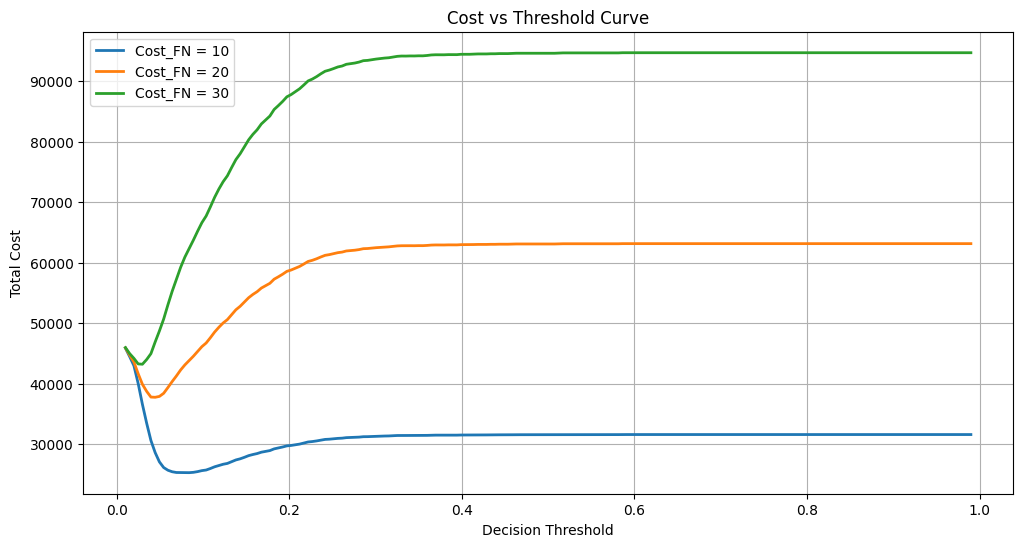

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def compute_cost_curve(probs, y_test, COST_FN, COST_FP=1):
    thresholds = np.linspace(0.01, 0.99, 200)
    costs = []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
        cost = COST_FN * fn + COST_FP * fp
        costs.append(cost)

    return thresholds, costs

# Compute curves
th10, cost10 = compute_cost_curve(probs, y_test, COST_FN=10)
th20, cost20 = compute_cost_curve(probs, y_test, COST_FN=20)
th30, cost30 = compute_cost_curve(probs, y_test, COST_FN=30)

# Plot
plt.figure(figsize=(12,6))
plt.plot(th10, cost10, label="Cost_FN = 10", linewidth=2)
plt.plot(th20, cost20, label="Cost_FN = 20", linewidth=2)
plt.plot(th30, cost30, label="Cost_FN = 30", linewidth=2)

plt.title("Cost vs Threshold Curve")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Cost")
plt.legend()
plt.grid(True)
plt.show()


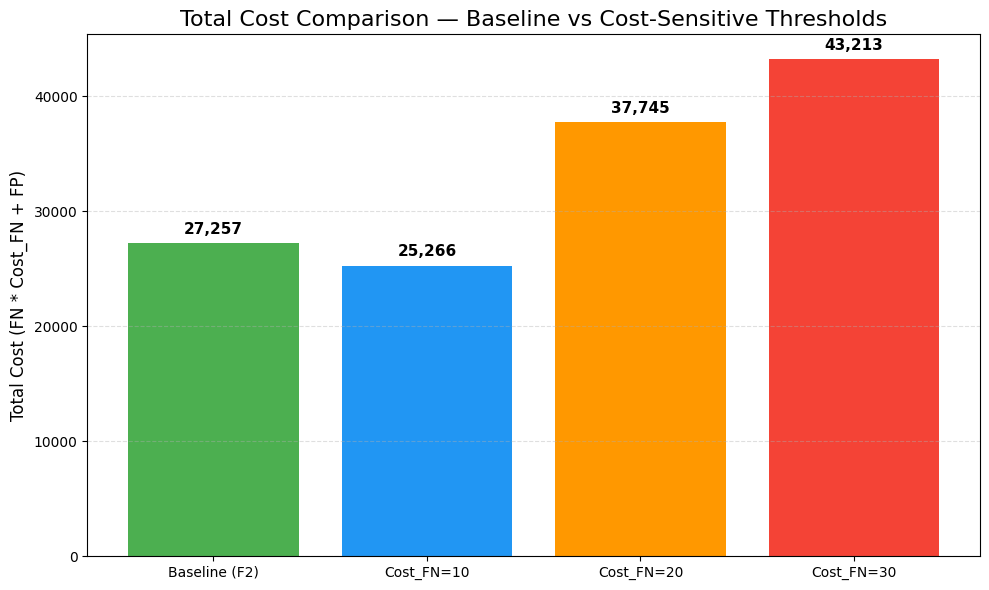

In [17]:
import matplotlib.pyplot as plt

# -----------------------------------------
# Your results
# -----------------------------------------
baseline_cost = 27257   # from baseline F2 model (FN*10 + FP)
cost_fn10 = 25266
cost_fn20 = 37745
cost_fn30 = 43213

methods = [
    "Baseline (F2)",
    "Cost_FN=10",
    "Cost_FN=20",
    "Cost_FN=30"
]

costs = [
    baseline_cost,
    cost_fn10,
    cost_fn20,
    cost_fn30
]

colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]

# -----------------------------------------
# Plot
# -----------------------------------------
plt.figure(figsize=(10,6))
bars = plt.bar(methods, costs, color=colors)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 800,
        f"{height:,}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Total Cost Comparison — Baseline vs Cost-Sensitive Thresholds", fontsize=16)
plt.ylabel("Total Cost (FN * Cost_FN + FP)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


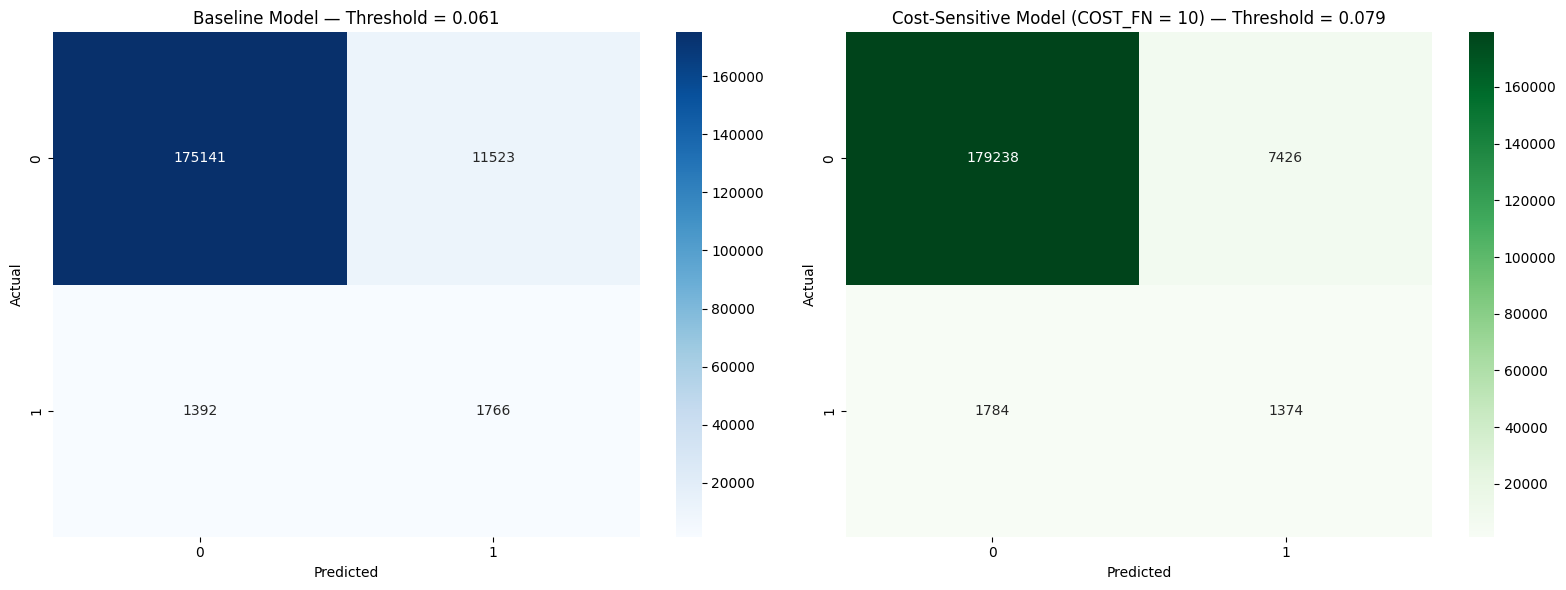

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------
# Baseline Confusion Matrix
# ---------------------------
cm_baseline = np.array([
    [175141, 11523],
    [  1392,  1766]
])

# ---------------------------
# Cost FN = 10 Confusion Matrix
# ---------------------------
cm_cost10 = np.array([
    [179238,  7426],
    [  1784,  1374]
])

# ---------------------------
# Plot both side-by-side
# ---------------------------
plt.figure(figsize=(16,6))

# Left: Baseline
plt.subplot(1,2,1)
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Model — Threshold = 0.061")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Right: Cost FN = 10
plt.subplot(1,2,2)
sns.heatmap(cm_cost10, annot=True, fmt="d", cmap="Greens")
plt.title("Cost-Sensitive Model (COST_FN = 10) — Threshold = 0.079")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()
